## Идеальный RAG pipeline

# Загрузка документов

## 1. Что делает document loader в RAG

Document loader – это "адаптер" между сырым источником данных (сайт, PDF, Notion, GitHub, YouTube и т.д.) и стандартным форматом `Document`, с которым дальше работает вся RAG-цепочка.

В LangChain все лоадеры реализуют общий интерфейс `BaseLoader` и, по сути, дают две операции

- `load()` – загрузить документы как есть;
- `loadAndSplit()` – загрузить и **сразу нарезать** на мелкие куски.

На уровне лоадера ты уже можешь контролировать качество сырья.

## 2. Какие ещё бывают лоадеры

LangChain делит лоадеры на **file loaders** и **web loaders**, плюс отдельные интеграции с облаком, продуктами и поиском.

**Основные категории**

[Document loaders - Docs by LangChain](https://docs.langchain.com/oss/python/integrations/document_loaders#by-category)

---

## 3. Оптимизация кода

### Текущий код


In [16]:
from langchain_community.document_loaders import WebBaseLoader
import os

os.environ["USER_AGENT"] = "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"

loader = WebBaseLoader('https://mt-lab.su/')
docs = loader.load()

### Что делает код

- Подменяет `USER_AGENT`, чтобы сайт не думал, что ты бот.
- Через `WebBaseLoader` скачивает **одну HTML-страницу** `главную`.
- Превращает её в список `Document` с сырой HTML/текстовой начинкой.

### Основные недостатки подхода

1. **Только одна страница**
    
    Если у продукта 10 страниц документации, ты сейчас используешь только одну. Остальные разделы (`/blog`, `/docs`, `/fees`, `/terms`) остаются вне индекса.
    
2. **Нет обхода ссылок `/sitemap`’а**
    
    FAQ часто ссылается на более подробные статьи. Код их не трогает: нет рекурсивного обхода и нет загрузки по `sitemap.xml`.
    
3. **Много мусорного текста**
    
    `WebBaseLoader` без настроек забирает всё: меню, футер, баннеры, кнопки, копирайт. Это ухудшает эмбеддинги и поиск – модель начинает видеть "cookie / subscribe / terms" как часть контента.
    
4. **Нет работы с другими форматами**
    
    Если у проекта есть PDF-whitepaper, презентации, Airtable с тарифами, GitHub-репо с примерами – они не попадают в базу вообще.
    
5. **Нет стратегии по обновлению**
    
    Пока это "один раз дернули URL". Для реальной системы нужна регулярная загрузка, чтобы FAQ не устаревал.

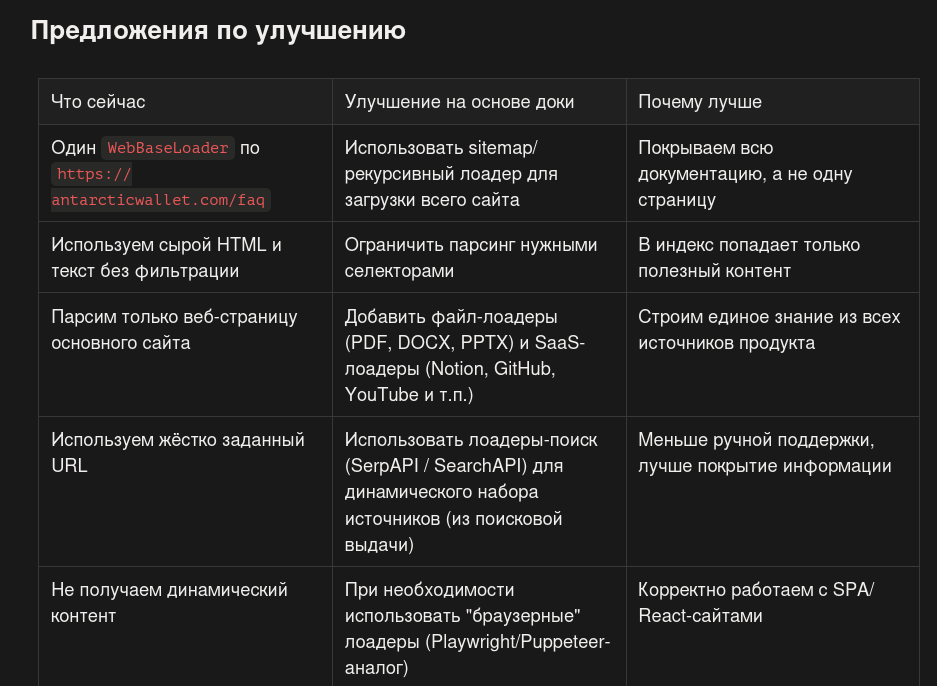



### Итоговый код

Для примера мы добавим мы улучшим только часть с тем, что мы парсим всего одну страницу. 

У большинства сайтов есть файл `sitemap.xml`.

Это официальный список всех страниц, которые сайт хочет индексировать (Google работает так же).

**SitemapLoader делает ровно то, что нужно для RAG:**

1. Скачивает `sitemap.xml`;
2. Достаёт из него все URL;
3. Загружает каждую страницу;
4. Возвращает список `Document` – по одному на страницу.

Таким образом: 

- Мы ничего не "придумываем"
- Не ходим по внешним ссылкам
- Получаем весь сайт целиком

https://mt-lab.su/ -- main

https://mt-lab.su/sitemap.xml | имеем три варианта (каталоги, продукты, о компании)

<sitemapindex>
<sitemap>
<loc>
https://mt-lab.su/sitemap-part-categories-index.xml --------> https://mt-lab.su/sitemap-part-categories-chunk-0.xml
</loc>
</sitemap>
<sitemap>
<loc>
https://mt-lab.su/sitemap-part-products-index.xml --------> https://mt-lab.su/sitemap-part-products-chunk-0.xml
</loc>
</sitemap>
<sitemap>
<loc>
https://mt-lab.su/sitemap-pages.xml --------> https://mt-lab.su/sitemap-pages.xml
</loc>
</sitemap>
</sitemapindex>


In [ ]:
# Загрузка документов
import os
from langchain_community.document_loaders import SitemapLoader, RecursiveUrlLoader

os.environ["USER_AGENT"] = "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"

ROOT_URL = "https://mt-lab.su/"
SITEMAP_URL = f"{ROOT_URL}/sitemap-part-categories-chunk-0.xml" # один из sitemap, который точно существует

# # 1) Загружаем все страницы из sitemap
# sitemap_loader = SitemapLoader(
#     web_path=SITEMAP_URL,
#     filter_urls=[ROOT_URL],  # на всякий случай ограничиваем доменом
# )

# sitemap_docs = sitemap_loader.load()

# only one page in sitemap
# Total documents: 18
# Total characters: 26043

# 2) Дополнительно рекурсивно обходим сайт от корня
recursive_loader = RecursiveUrlLoader(
    url=ROOT_URL,
    max_depth=1,          # глубину при желании можно увеличить
    prevent_outside=True  # не выходим за пределы домена
)
docs = recursive_loader.load()

# depth=1
# Total documents: 1
# Total characters: 123335

# depth=2
# Total documents: 29
# Total characters: 2808801

# depth=3
# Total documents: 34
# Total characters: 3160292


# # 3) Объединяем всё в один список документов для RAG
# # docs = sitemap_docs + recursive_docs
# docs = recursive_docs

print(f"Total documents: {len(docs)}")
print(f"Total characters: {sum(len(doc.page_content) for doc in docs)}")

Total documents: 1
Total characters: 123335


# Разделение документов на кусочки (split)

## 1. Что делает text splitter в RAG

Text splitter – это слой между "сырыми" документами и эмбеддингами. Его задача:

- **разбить длинный текст на кусочки**, которые:
    - поместятся в контекст модели,
    - можно доставать по отдельности из векторного хранилища;
- **сохранить смысл и структуру** внутри каждого кусочка (не рвать предложения и логические блоки, где это возможно).

В LangChain рекомендуют в качестве дефолта `RecursiveCharacterTextSplitter`: он сначала пытается сохранить большие блоки (параграфы), если они не влезают – переходит на более мелкие единицы (предложения, слова).

## 2. Какие бывают стратегии разделения

В доке текстовые сплиттеры делят на три группы:

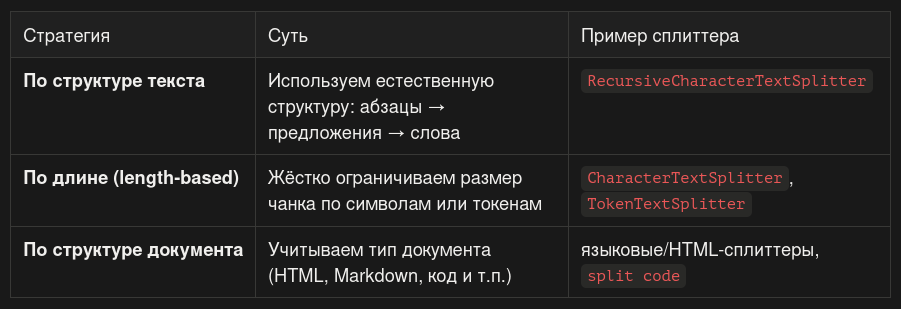

Коротко:

- **RecursiveCharacterTextSplitter** – хороший универсальный старт.
- **TokenTextSplitter** – когда важно строго уложиться в лимит токенов модели.
- **Языковые/HTML/Markdown-сплиттеры** – когда важно не рвать структуру документа (код, HTML, Markdown и т.п.).

## 3. Оптимизация кода

Текущий код

In [4]:
# Разделение документов на кусочки (split)
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)
splits = text_splitter.split_documents(docs)

### Что делает код

- Использует `RecursiveCharacterTextSplitter` с:
    - `chunk_size=1000` символов,
    - `chunk_overlap=200` символов перекрытия.
- Сплиттер идёт по иерархии разделителей: параграфы → предложения → слова, пока не уложится в заданный размер.

### Основные недостатки подхода

1. **Ориентир на символы, а не токены**
    
    Модель ограничена токенами, а не символами. 1000 символов в русском/HTML могут давать сильно разное число токенов. В доке отдельно подчёркивают, что для RAG удобно считать именно токены.
    
2. **Один и тот же сплиттер для любого типа текста**
    
    Сейчас документы режутся как обычный "плоский текст", хотя по факту это HTML-страницы со своей структурой (заголовки, секции, списки, блоки FAQ). Из-за этого один логический блок может быть разрезан посередине, а разные части страницы – склеены в один чанк.

    В LangChain есть структурные режимы сплиттинга, например `RecursiveCharacterTextSplitter.from_language(Language.HTML)`, которые знают, где в HTML находятся естественные границы (заголовки, блоки контента) и стараются резать текст именно по ним. В результате каждый чанк соответствует законченному разделу страницы, что напрямую улучшает качество поиска и ответов в RAG.

3. **Параметры выбраны "на глаз"**
    
    `chunk_size=1000` / `chunk_overlap=200` никак не привязаны:
    
    - к контексту конкретной модели (4k/8k/16k токенов),
    - к типу задач (QA vs суммаризация).
        
        В документации советуют начинать с разумного дефолта и дальше подстраивать под приложение.
        

### Предложения по улучшению

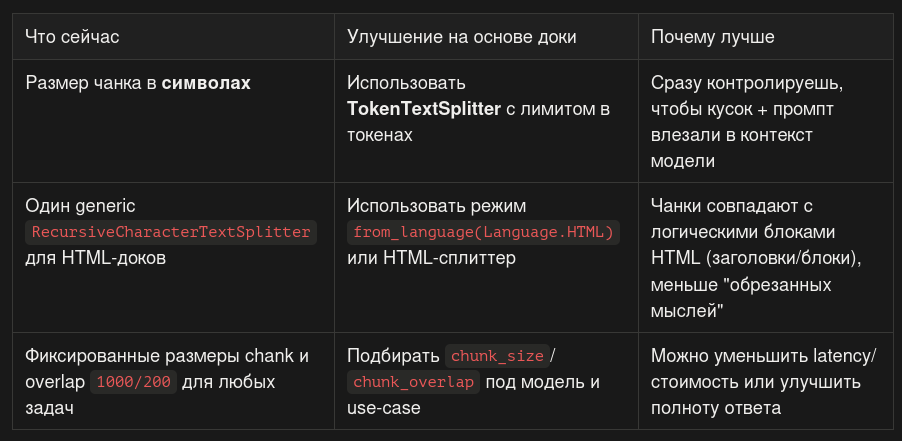



### Итоговый код

**Вариант 1. HTML-ориентированный split через язык**

Этот вариант лучше подходит как раз для страниц, которые ты грузишь с сайта (HTML):

In [18]:
from langchain_text_splitters import RecursiveCharacterTextSplitter, Language

text_splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.HTML,   # учитываем структуру HTML
    chunk_size=1200,          # немного больше, т.к. структура сохраняется лучше
    chunk_overlap=200,
)

splits = text_splitter.split_documents(docs)

Что меняется:

- сплиттер использует преднастроенные разделители для HTML (`Language.HTML`), а не общий список;
- чанки будут ближе к реальным блокам страницы (секции, div’ы, заголовки).

**Вариант 2. Токен-базовый split под лимиты модели**

In [7]:
from langchain_text_splitters import TokenTextSplitter

token_splitter = TokenTextSplitter(
    chunk_size=256,   # в токенах
    chunk_overlap=32, # тоже в токенах
)

splits = token_splitter.split_documents(docs)

Это хороший шаг для продакшена:

> "Сначала мы делим логично (HTML/структура), а дальше – контролируем токены, чтобы точно не вылетать из контекста модели".
> 

# Создание embeddings

## 1. Что такое embeddings в RAG

Embeddings – это способ превратить текст в числовой вектор так, чтобы **похожие по смыслу тексты имели похожие вектора**.

Именно embeddings позволяют RAG-системе делать **семантический поиск**, а не искать совпадения слов.

В RAG embeddings используются в двух местах:

1. **При индексации** – когда мы превращаем документы (чанки) в вектора и кладём их в vector store.
2. **При запросе пользователя** – когда вопрос тоже превращается в вектор и сравнивается с документами.

Одна и та же embedding-модель должна использоваться и для документов, и для запросов.

## 2. Какие бывают embedding-модели

В LangChain embedding-модели – это отдельные интеграции, каждая из которых реализует единый интерфейс `Embeddings`.

По сути, у любой модели есть два метода:

- `embed_documents()` – для документов;
- `embed_query()` – для пользовательского запроса.

### Основные категории embedding-моделей

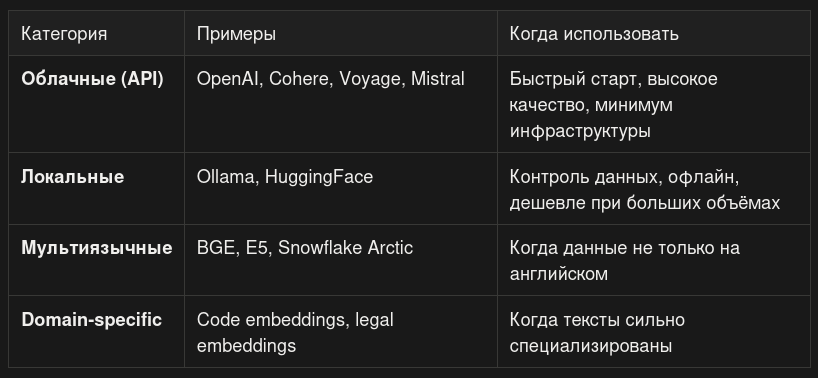

В документации LangChain прямо подчёркивается: выбор embedding-модели – один из самых важных факторов качества RAG.

## 3. Оптимизация кода

### Текущий код

In [ ]:
# Создаём embeddings
from langchain_ollama import OllamaEmbeddings

EMBEDDING_MODEL = "hf.co/Casual-Autopsy/snowflake-arctic-embed-l-v2.0-gguf:Q4_K_M"
OLLAMA_EMBEDDING_BASE_URL = "http://127.0.0.1:11434"

embeddings = OllamaEmbeddings(
    model=EMBEDDING_MODEL,
    base_url=OLLAMA_EMBEDDING_BASE_URL,
)

req = embeddings.embed_query("Привет, как дела?")  # пример запроса для получения эмбеддингов
print(req)

[-0.010314466, -0.0068332716, -0.04557045, -0.050392352, -0.026100751, 0.032460395, 0.049847193, 0.058093097, -0.02185408, -0.020544926, 0.00034323902, 0.023748543, 0.006529608, 0.018157274, 0.017760955, 0.03421844, 0.06474504, -0.017354237, -0.021317316, -0.009938152, -0.010055061, 0.09630137, 0.007446229, -0.032199826, 0.08336375, -0.0048895204, -0.029667145, -0.015686916, -0.008830524, -0.059846133, -0.0061580725, 0.03231899, 0.06828636, -0.077467285, 0.02209612, -0.00026299342, 0.04112918, -0.050867505, -0.11067985, 0.03898202, -0.0144107565, 0.0036066948, -0.03863445, -0.038605984, 0.0042554447, -0.002831468, -0.03366079, -0.076285355, 0.0006399257, -0.002178669, -0.033787183, 0.0144850025, -0.0055944785, 0.0057398477, -0.029769607, 0.036479216, -0.0018650802, -0.0552541, -0.023556184, -0.019984042, 0.056674086, 0.026509663, 0.029147388, -0.025920251, -0.08010405, 0.059822246, 0.0032306148, -0.0010338476, -0.018334093, -0.024590192, -0.05905939, 0.008276605, 0.026122814, 0.0188892

### Что делает код

- Использует **локальную embedding-модель** через Ollama.
- Модель `snowflake-arctic-embed-l` – современная embedding-модель общего назначения.
- Все embeddings считаются **локально**, без отправки данных во внешние API.

Это хороший продакшн-ориентированный старт, но есть нюансы.

### Основные недостатки подхода

1. **Модель выбрана без привязки к языку данных**
    
    Модель Arctic – сильная, но изначально ориентирована на английский. Если в документах много русского текста, качество семантического поиска может быть хуже, чем у специализированных мультиязычных моделей.
    
2. **Не учитывается размер эмбеддинга**
    
    Разные модели возвращают вектора разной размерности (384, 768, 1024, 1536+).
    
    Чем больше размер – тем:
    
    - больше память vector store;
    - медленнее поиск.
        
    В коде это никак не учитывается и выбирается "самая большая" модель по умолчанию.

3. **Нет стратегии под use-case**
    
    Embedding-модель выбирается одинаково для:
    
    - FAQ,
    - длинных документов,
    - коротких ответов.
        
    В доках LangChain рекомендуют подбирать модель под задачу: QA, поиск, кластеризация, code-search и т.д.
        
4. **Нет fallback-варианта**
    
    Если Ollama недоступна или модель не прогрелась – пайплайн падает. В продакшене часто держат облачную модель как запасной вариант.
    

### Предложения по улучшению

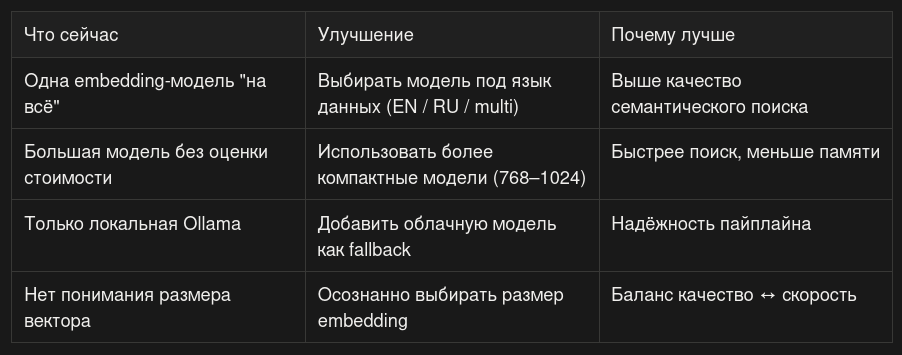

### Итоговый код

В качестве улучшения мы просто поменяем модель `snowflake-arctic-embed-l` на модель от российского разработчика:

https://huggingface.co/ai-forever/ru-en-RoSBERTa

In [19]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.embeddings import Embeddings

# Базовая модель
base_embeddings = HuggingFaceEmbeddings(
    model_name="ai-forever/ru-en-RoSBERTa"
)

class PrefixedEmbeddings(Embeddings):
    def __init__(self, base, query_prefix="", doc_prefix=""):
        self.base = base
        self.query_prefix = query_prefix
        self.doc_prefix = doc_prefix

    def embed_documents(self, texts):
        texts_prefixed = [self.doc_prefix + t for t in texts]
        return self.base.embed_documents(texts_prefixed)

    def embed_query(self, text):
        return self.base.embed_query(self.query_prefix + text)

embeddings = PrefixedEmbeddings(
    base_embeddings,
    query_prefix="search_query: ",
    doc_prefix="search_document: ",
)

print(embeddings.embed_query("Привет, как дела?"))

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 1569.18it/s]
RobertaModel LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                 | Status  | 
--------------------+---------+-
pooler.dense.weight | MISSING | 
pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[0.009199555963277817, -0.010738550685346127, -0.0012247703270986676, 0.010181044228374958, 0.017092565074563026, 0.035003598779439926, -0.019326118752360344, -0.007804022170603275, -0.00691161910071969, -0.06191858649253845, 0.006163228768855333, -0.03864208981394768, -0.03135858103632927, 0.017288440838456154, 0.020299552008509636, -0.006605944130569696, 0.03888862952589989, -0.027151623740792274, -0.008253038860857487, 0.010795585811138153, 0.0035497730132192373, 0.013414313085377216, 0.011716409586369991, 0.020851418375968933, -0.03943091630935669, 0.03055892512202263, -0.023713458329439163, 0.01566658541560173, 0.00541088217869401, -0.045147188007831573, -0.0008733912254683673, 0.008185787126421928, 0.007946779951453209, 0.010393242351710796, -0.05370964854955673, -0.018061308190226555, -0.013933714479207993, -0.02774936333298683, -0.03351343795657158, -0.05034078657627106, -0.014550563879311085, -0.04316791519522667, -0.019976818934082985, -0.0038029749412089586, -0.0174538921564

Почему так лучше:

- одинаково хорошо работает с RU и EN;
- меньше "потерь смысла" при смешанных языках.
- Зачем добавили класс `PrefixedEmbeddings`
    
    **Проблема:**
    
    Embedding-модель получает документы и пользовательские запросы в одинаковом виде – просто как текст. Для неё нет разницы, где база знаний, а где вопрос. При этом многие современные embedding-модели (в том числе RoSBERTa-подобные) обучались с явным разделением типов текста: *документы* и *поисковые запросы* подавались с разными текстовыми префиксами. Без этого модель работает, но использует свой потенциал не полностью.
    
    **Решение:**
    
    Мы добавили класс `PrefixedEmbeddings`, который автоматически:
    
    - добавляет префикс `search_document:` ко всем документам;
    - добавляет префикс `search_query:` к запросам пользователя.
    
    Таким образом модель начинает понимать **роль текста**, а не только его содержание. Это повышает качество семантического поиска и релевантность ответов в RAG, при этом весь остальной пайплайн LangChain (vector store, retriever, цепочки) остаётся без изменений.

- Ошибка `Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized`
    
    Это предупреждение означает, что в чекпоинте модели `ai-forever/ru-en-RoSBERTa` отсутствуют веса верхнего `pooler`-слоя, поэтому библиотека `transformers` инициализирует его случайно и сообщает об этом. `Pooler` используется в задачах классификации или предсказаний "на уровне всего текста", но при создании эмбеддингов в RAG он, как правило, не участвует – векторы берутся из скрытых слоёв модели (например, через усреднение токенов или CLS-вектор). Поэтому дообучать модель в нашем случае не требуется, и это предупреждение не влияет на качество семантического поиска или работу RAG-системы.

# Векторные хранилища

## 1. Что делает vector store в RAG

Vector store – это слой, который отвечает за **хранение эмбеддингов** и **поиск по смыслу**.

Именно здесь происходит ключевая операция RAG: поиск фрагментов текста, которые **семантически близки** к вопросу пользователя.

Проще говоря:

- документы → превращаются в embeddings;
- embeddings → сохраняются в vector store;
- вопрос пользователя → тоже превращается в embedding;
- vector store ищет **ближайшие вектора** и возвращает связанные документы.

В LangChain все vector store реализуют единый интерфейс, поэтому почти любой backend можно заменить без переписывания RAG-цепочки.

## 2. Какие бывают vector store

LangChain поддерживает десятки векторных хранилищ – от локальных до облачных и распределённых.

**Основные категории**

[Vector stores – Docs by LangChain](https://docs.langchain.com/oss/javascript/integrations/vectorstores?utm_source=chatgpt.com)

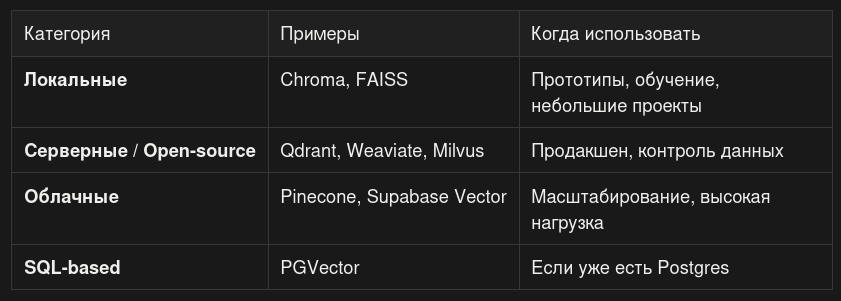

vector store – это инфраструктурный выбор, а не часть бизнес-логики. Его можно заменить, если правильно выстроен интерфейс.

---

## 3. Оптимизация кода

### Текущий код

In [ ]:
from langchain_community.vectorstores import Chroma

persist_directory = "./chroma_db"

vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory=persist_directory,
)

### Что делает код

- Берёт готовые чанки `splits`;
- Считает для них embeddings;
- Создаёт локальное vector store **Chroma**;
- Сохраняет индекс на диск в `./chroma_intro_db`.

### Основные недостатки подхода

1. **Индекс пересобирается при каждом запуске**
    
    `Chroma.from_documents(...)` каждый раз:
    
    - заново считает embeddings;
    - пересоздаёт коллекцию.
    
    При росте данных это становится:
    
    - медленно,
    - дорого,
    - неудобно для обновлений.

2. **Нет инкрементального обновления**
    
    Если добавился один новый документ:
    
    - приходится пересобирать весь индекс,
    - нельзя просто "добавить ещё".
3. **Не используются метаданные**
    
    Без метаданных нельзя:
    
    - фильтровать документы по источнику (`faq`, `blog`, `terms`);
    - ограничивать поиск по типу или дате;
    - управлять релевантностью.
4. **Chroma выбран без объяснения альтернатив**
    
    Chroma отлично подходит для старта, но:
    
    - не всегда оптимален для больших объёмов;
    - не масштабируется горизонтально;
    - не всегда подходит для продакшена.

Предложения по улучшению

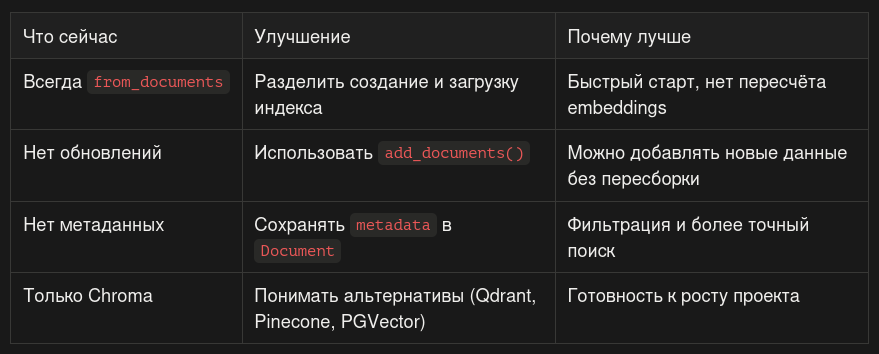

### Итоговый код

Для примера улучшим **только один момент** – избавимся от пересоздания индекса при каждом запуске.

In [20]:
from pathlib import Path
from langchain_community.vectorstores import Chroma

persist_directory = "./chroma_db_mt_lab"

if Path(persist_directory).exists():
    # Индекс уже есть – просто загружаем
    vectorstore = Chroma(
        embedding_function=embeddings,
        persist_directory=persist_directory,
    )
else:
    # Первый запуск – создаём индекс
    vectorstore = Chroma.from_documents(
        documents=splits,
        embedding=embeddings,
        persist_directory=persist_directory,
    )

Теперь:

- embeddings считаются **один раз**;
- последующие запуски поднимают готовый индекс;
- код остаётся простым и понятным;
- появляется возможность дальше:
    - добавлять документы,
    - удалять их,
    - мигрировать на другой vector store.

# Настройка `retriever`

## 1. Что делает retriever в RAG

Retriever – это компонент, который **выбирает нужные куски текста из базы знаний по вопросу пользователя**.

Его задача – решить простую, но критичную задачу: **какие именно фрагменты документов стоит отдать модели, чтобы она смогла ответить правильно**.

Как это выглядит на практике:

- пользователь задаёт вопрос обычным текстом;
- retriever ищет в базе знаний подходящие фрагменты;
- возвращает несколько документов с текстом (`page_content`) и служебной информацией (`metadata`);
- **только эти документы** дальше передаются в LLM.

Важно понимать:

- retriever работает **до LLM** и определяет, что модель вообще увидит;
- vector store можно "превратить" в retriever через `.as_retriever()`, но есть и другие типы retriever’ов (BM25, Arxiv, web-поиск, long-term memory и т.д.).
    
    [Retrievers - Docs by LangChain](https://docs.langchain.com/oss/javascript/integrations/retrievers)
    

Retriever – это точка, где ты управляешь **стратегией поиска**, а не только хранилищем.

---

## 2. Какие ещё бывают retrievers

На уровне LangChain retriever – это любой компонент, реализующий интерфейс "запрос → список документов".

**Примеры из документации**

[Retrievers – Docs by LangChain](https://docs.langchain.com/oss/javascript/integrations/retrievers?utm_source=chatgpt.com)

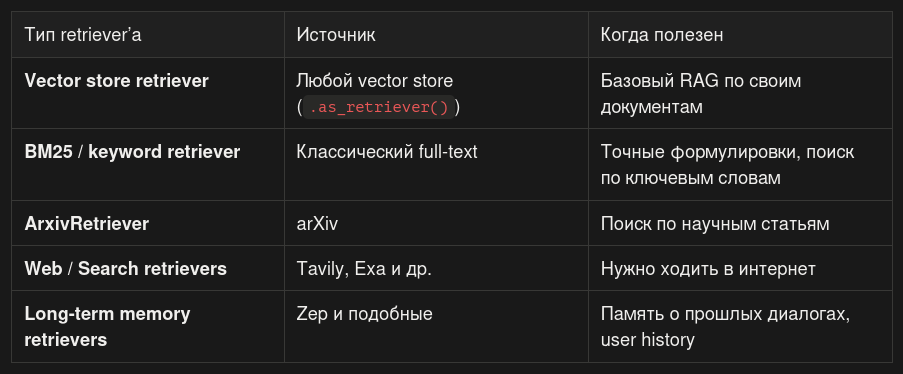

Идея для урока:

> "Retriever – это не всегда векторное хранилище. Это универсальный слой поиска, который можно подменять под задачу".
> 

---

## 3. Оптимизация кода

### Текущий код

In [ ]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

### Что делает код

- Берёт твой `vectorstore` (Chroma или другой);
- Превращает его в retriever;
- Настраивает только один параметр поиска: `k=5` – возвращать 5 ближайших документов по похожести.

Это нормальный дефолт, но он использует **минимум возможностей**.

---

### Основные недостатки подхода

1. **Жёстко зашитое `k=5` для любых запросов**
    - Иногда 5 документов мало (сложный вопрос).
    - Иногда много (короткий факт).
    
    Без адаптации под задачу retriever может:

    - либо не находить нужный контекст,
    - либо давать лишний шум.

2. **Нет фильтрации по метаданным**
    
    Retriever сейчас смотрит только на **похожесть по вектору**, но игнорирует:
    
    - `source` (faq/blog/terms),
    - дату,
    - тип документа (FAQ, туториал, changelog),
    - язык и т.п.
    
    То есть вопрос "Комиссия за вывод?" может приводить документы из ни разу не FAQ, если они векторно близки.
    
3. **Используется только один режим поиска**
    
    `.as_retriever()` по умолчанию делает обычный similarity search.
    
    Но многие vector store (и retriever’ы) поддерживают:
    - **MMR (max marginal relevance)** – баланс между релевантностью и разнообразием;
    - MMR
        
        MMR (Max Marginal Relevance) – это стратегия поиска, которая выбирает документы не только по близости к запросу, но и с учётом того, **насколько они отличаются друг от друга**. В обычном similarity search retriever часто возвращает несколько почти одинаковых чанков (например, с одной страницы), тогда как MMR старается собрать набор документов, который одновременно релевантен запросу и разнообразен по содержанию. 
        
        Плюс MMR в том, что модель получает более "широкий" контекст и меньше повторов, что особенно полезно для вопросов с несколькими аспектами. 
        
        Минусы – MMR работает чуть медленнее (нужно рассматривать больше кандидатов) и иногда может включить менее релевантный документ ради разнообразия, если параметры подобраны неудачно.
        
- разные distance metrics / scoring;
- гибридные режимы (vector + keyword).

Игнорирование этих настроек ограничивает качество поиска.

4. **Нет альтернативных retriever’ов**
    
    Сейчас у тебя есть только **одна стратегия**: vector search.
    
    Но в LangChain можно добавить:
    
    - BM25Retriever для точного текстового поиска;
    - web retriever (Tavily/Exa) для доп. контекста из интернета;
    - спец. retrievers (Arxiv, Zep и т.п.).

Предложения по улучшению

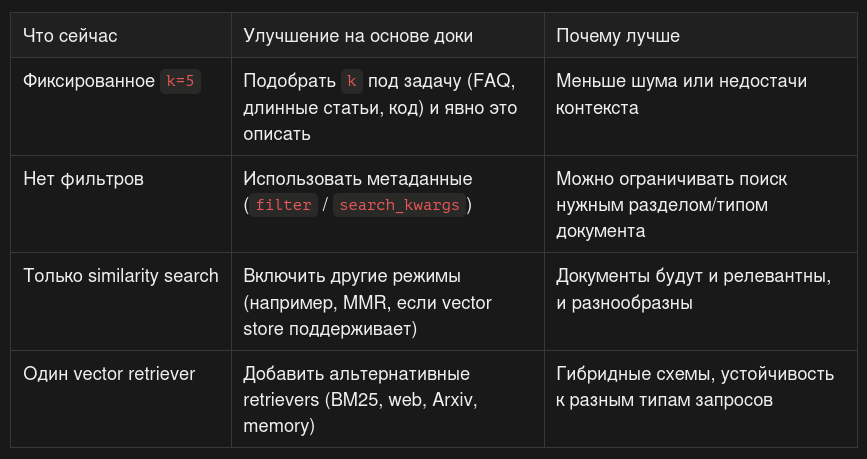

Итоговый код:

In [31]:
# 1. Базовый retriever с MMR (разнообразные документы)
retriever = vectorstore.as_retriever(
    search_type="mmr",  # вместо простого similarity
    search_kwargs={
        "k": 8,          # сколько документов вернуть в итоге
        "fetch_k": 32,   # из скольких кандидатов выбирать (больше = разнообразнее)
        # при желании можно добавить lambda_mult для тонкой настройки
        # lambda_mult – это параметр MMR, который задаёт баланс между релевантностью документов запросу и их разнообразием: чем ближе значение к 1, тем сильнее приоритет близости к запросу, чем ближе к 0 – тем важнее разнообразие результатов.
        "lambda_mult": 0.8,
    },
)


# # 2. Более строгий retriever с порогом релевантности
# strict_retriever = vectorstore.as_retriever(
#     search_type="similarity_score_threshold",  # similarity_score_threshold – это режим поиска, при котором retriever возвращает только те документы, чья семантическая близость к запросу выше заданного порога, отсекая слабые и нерелевантные совпадения.
#     search_kwargs={
#         "score_threshold": 0.4,  # score_threshold – это порог релевантности (число от 0 до 1), который определяет минимальную допустимую степень семантической близости документа к запросу: чем выше значение, тем строже отбор, но более точные результаты.
#         "k": 8,                 # максимум кандидатов, которые вообще рассматриваем
#     },
# )


# # 3. Пример retriever только по FAQ (если в metadata есть source)
# faq_retriever = vectorstore.as_retriever(
#     search_type="mmr",
#     search_kwargs={
#         "k": 6,
#         # фильтр по метаданным – ключи должны совпадать с тем,
#         # что ты кладёшь в doc.metadata при индексации
#         "filter": {"source": {"$contains": "faq"}},
#     },
# )

- `format_docs` (напишем ниже) начнёт чаще видеть **разные `Source` и `Page`**, а не 5 раз одну и ту же страницу – контекст станет богаче по информации.
- Порог релевантности защитит от ситуаций, когда retriever по привычке возвращает "что-нибудь, лишь бы не пусто" – лучше меньше, но по делу.
- Фильтры по метаданным позволят делать отдельные retriever’ы под FAQ, юридические тексты, changelog и т.д., не смешивая всё в одном ответе.

# Post-processing (функция `format_docs`)

## 1. Что делает post-processing в RAG

После retriever’а у нас есть **список документов** (чанков), а в промпт модели нужно передать **одну строку контекста**.

Post-processing – это этап, на котором мы:

- форматируем каждый документ (добавляем заголовки, источники и т.п.);
- соединяем их в одну строку;
- при необходимости чистим/режем, чтобы контекст не разъехался по токенам.

В LangChain это делает так называемая *“stuff documents chain”*: она форматирует каждый документ по шаблону `document_prompt`, соединяет их через `document_separator` и кладёт в переменную `context`, которая дальше уходит в промпт.

## 2. Какие ещё бывают варианты пост-обработки

Post-processing не ограничивается простым `"\n\n".join(...)`. Вокруг retrieved-документов можно делать много полезных вещей:

**Типичные приёмы:**

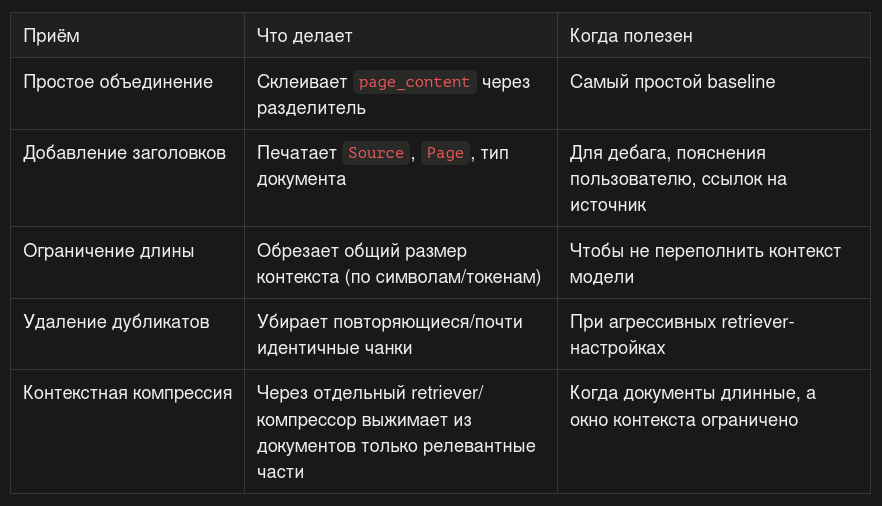

LangChain прямо выделяет post-processing как важный шаг: например, `ContextualCompressionRetriever` специально создан для того, чтобы **обрезать из retrieved-доков всё нерелевантное**, прежде чем они попадут в промпт.

---

## 3. Оптимизация кода

### Текущий код

In [ ]:
# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

### Что делает код

- Берёт список `docs` от retriever’а;
- забирает из каждого только `page_content`;
- склеивает все тексты подряд через двойной перенос строки.

Это минимальный рабочий вариант: модель получает контекст, но “слепой” – без информации об источниках и структуре.

### Основные недостатки подхода

1. **Теряется информация об источнике**
    
    В `doc.metadata` обычно лежат полезные поля: `source`, `page`, `section`, `url` и т.д.
    
    Ты их уже аккуратно задаёшь на этапах загрузки/сплиттинга, но здесь они просто игнорируются.
    
2. **Сложнее дебажить и доверять ответам**
    
    Если модель галлюцинирует или даёт спорный ответ, по такому контексту тяжело понять:
    
    - из какого файла/страницы она это взяла;
    - был ли там вообще такой текст.

3. **Нет визуальных границ между документами**
    
    Двойной `\n\n` иногда недостаточен: длинные куски текста сливаются, и модели сложнее понимать, где заканчивается один источник и начинается другой.
    
    В LangChain’овской `StuffDocumentsChain` для этого как раз есть `document_separator`.
    

### Итоговый код

Доведём функцию `format_docs` до аккуратного “продакшн-минимума”:

In [32]:
MAX_CHARS = 10_000

def format_docs(docs):
    formatted = []
    total_len = 0

    for doc in docs:
        source = doc.metadata.get("source", "unknown_source")
        page = doc.metadata.get("page", None)

        header = f"Source: {source}"
        if page is not None:
            header += f" | Page: {page}"

        text = doc.page_content.strip()
        block = f"{header}\n{text}"

        # если следующий блок слишком раздует контекст – останавливаемся
        if total_len + len(block) > MAX_CHARS:
            break

        formatted.append(block)
        total_len += len(block)

    return "\n\n---\n\n".join(formatted)

**Что улучшилось:**

- Появился **явный заголовок для каждого блока** с указанием источника (`Source`) и страницы (`Page`).
- Контекст стал **чётко структурированным**: каждый документ оформлен как отдельный логический блок.
- Между документами добавлен **визуальный и смысловой разделитель** `\n\n---\n\n`, уменьшающий "склеивание" смыслов.
- Используется информация из `doc.metadata`, которая раньше **полностью игнорировалась**.
- Текст каждого документа **очищается от лишних пробелов** по краям с помощью `strip()`.
- Добавлено **ограничение на общий размер контекста** (`max_chars`), что защищает от переполнения контекстного окна модели.
- Контекст формируется **детерминированно**: документы добавляются последовательно и обрезаются в предсказуемом месте.
- Функция стала **расширяемой точкой пайплайна** – сюда легко добавить фильтрацию, дедупликацию или компрессию контекста в будущем.

# Системный промпт

## 1. Что делает системный промпт в RAG

Системный промпт – это сообщение уровня *"system"*, которое задаёт **роль и правила поведения модели**: на каком языке отвечать, что можно/нельзя делать, как работать с контекстом и что делать, если ответа нет.

В `ChatPromptTemplate` системный промпт – первая часть шаблона диалога, к нему потом добавляются сообщения пользователя (`human`) и, при необходимости, история (`MessagesPlaceholder("history")`).

В RAG через системный промпт мы обычно фиксируем три вещи:

- **откуда брать знания** (только из `{context}`, не фантазировать);
- **как отвечать** (язык, стиль, формат);
- **что делать, если информации недостаточно** (честно сказать, что не знаем).

---

## 2. Какие есть возможности у ChatPromptTemplate

`ChatPromptTemplate` позволяет гибко собирать промпт из нескольких сообщений и переиспользовать его.

https://reference.langchain.com/python/langchain-core/prompts

Основные возможности:

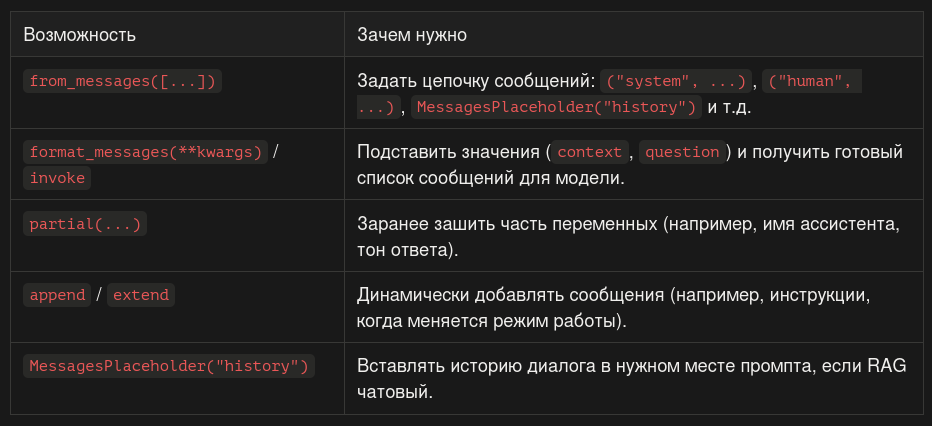

Системный промпт – это не одна строка, а часть нормально структурированного чат-шаблона, который можно версионировать, сохранять и дорабатывать.

---

## 3. Оптимизация кода

### Текущий код

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a precise analytical assistant specializing in laboratory equipment of MT-LAB."
        "Always respond in the same language the user used in their question. "
        "Rules:\n"
        "- Answer ONLY based on the provided context\n"
        "- If the answer is not in the context, say so directly — do not guess\n"
        "- Do not use external knowledge or make assumptions\n"
        "- Be concise but complete — include formulas, steps, or examples if present in context\n"
        "- If context contains contradictions, point them out\n"
        "- Always end your answer with: Sources: [list the source filenames used]"
    ),
    (
        "human",
        "Context:\n{context}\n\nQuestion: {question}"
    ),
])

### Что делает код

- Создаёт `ChatPromptTemplate` с:
    - одним системным сообщением (жёстко фиксирует язык = русский, краткость, запрет иностранных слов);
    - одним human-сообщением, куда подставляются `{context}` и `{question}`.

Это уже лучше, чем "одна сырая строка-промпт", но есть куда улучшать.

### Основные недостатки подхода (НЕ ДЛЯ ЭТОГО ПРОМПА, НО ПОМНИТЬ!)

1. **Слишком жёсткое ограничение по длине и стилю**
    
    > "Используй максимум три предложения"
    > 
    
    Для многих вопросов по документации этого мало:
    
    нормальный RAG-ответ иногда требует 4–6 предложений, списков, пояснений.
    
    Сейчас промпт скорее оптимизирован "на демо", а не на полезность.
    
2. **Запрет иностранных слов до абсурда**
    
    > "Не используй слова и фразы на других языках"
    > 
    
    Это может мешать:
    
    - корректно написать названия тарифов, API-методов, параметров (`withdrawal_fee`, `GET /v1/...`);
    - оставить оригинальные имена кнопок/полей.
    
    Модель будет пытаться "перевести" то, что лучше оставить как есть.
    
3. **Нет явных инструкций по работе с контекстом**

    Системный промпт говорит "Используй фрагменты контекста", но не уточняет:

    - что делать, если контекст противоречивый;
    - как поступать, если контекст пустой/очень короткий;
    - как использовать `Source`/`Page`, которые ты добавляешь в `format_docs`.

    Можно явно сказать:

    > "если ссылаешься на информацию, указывай источник/страницу из заголовка".
    > 
4. **Нет места для истории диалога**
    
    Сейчас это шаблон в стиле "один вопрос – один ответ".
    
    Если ты захочешь сделать чат с историей, придётся менять промпт. В `ChatPromptTemplate` есть `MessagesPlaceholder("history")`, и лучше сразу заложить структуру под чат.

Предложения по улучшению

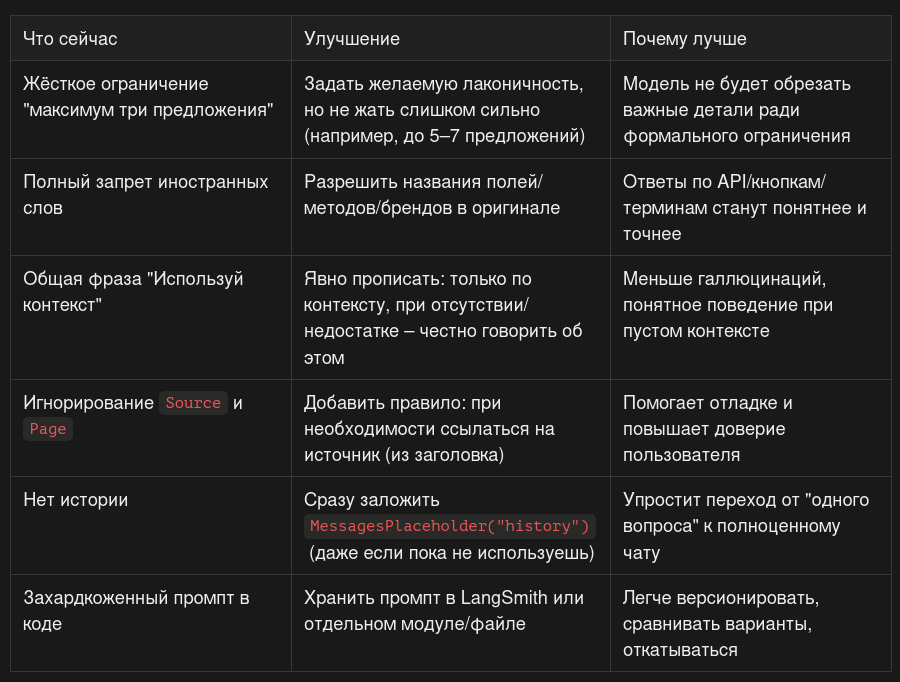

### Итоговый код

Сделаем умеренно строгий системный промпт под RAG, с учётом формата контекста (`Source: ... | Page: ...` – из функции `format_docs`) и возможного чата.

In [33]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompts import MessagesPlaceholder

prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a precise analytical assistant specializing in laboratory equipment of MT-LAB. "
        "Always respond in the same language the user used in their question. "
        "Rules:\n"
        "- Answer ONLY based on the provided context\n"
        "- If the answer is not in the context, say so directly — do not guess\n"
        "- Do not use external knowledge or make assumptions\n"
        "- Be concise but complete — include formulas, steps, or examples if present in context\n"
        "- If context contains contradictions, point them out\n"
        "- Always end your answer with: Sources: [filename, page X] for each chunk used"
    ),
    MessagesPlaceholder("history"),
    (
        "human",
        "Context:\n{context}\n\nQuestion: {question}"
    ),
])

Что мы улучшили:

- **Сняли слишком жёсткий лимит** в n_max предложения, но сохранили требование лаконичности.
- Чётко зафиксировали: **только по контексту, без фантазии**.
- Прописали поведение, если ответа нет: "не нашёл в базе".
- Дали модели знать, что `Source` и `Page` – это важные поля, которые можно использовать в ответах.
- Сразу заложили `history` как точку расширения под чат.

# LLM-модель (языковая модель)

## 1. Что делает LLM в RAG

LLM (Large Language Model) – это **последний этап RAG-цепочки**, который:

- получает **вопрос пользователя**;
- получает **контекст**, отобранный retriever’ом и отформатированный (`format_docs`);
- **формулирует ответ**, опираясь на системный промпт и переданный контекст.

Важно:

В RAG **LLM не ищет информацию** и не принимает решений о том, *что* подать в контекст.

Она только отвечает на основе того, **что ей дали**.

Поэтому в RAG LLM – это:

> не "умная база знаний", а интерпретатор и генератор ответа.
> 

---

## 2. Какие бывают LLM в LangChain

LangChain отделяет **тип модели** от **провайдера**, поэтому один и тот же код может работать с локальной моделью, OpenAI, Anthropic и т.д.

### Основные типы моделей

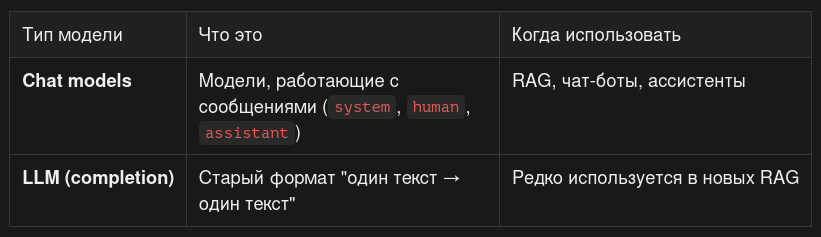

В RAG почти всегда используются **chat-модели**.

---

### Провайдеры chat-моделей

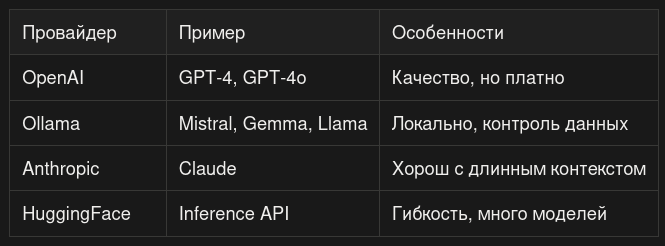

LangChain даёт **единый интерфейс**, поэтому смена модели – это замена 2–3 строк кода.

---

## 3. Оптимизация кода

### Текущий код



In [ ]:
# Будем использовать модель с поддержкой Русского языка:
# ollama pull gemma3:4b

from langchain_openai import ChatOpenAI

OLLAMA_BASE_URL = 'http://127.0.0.1:11434/v1'
LLM_MODEL = 'gemma3:4b'

llm = ChatOpenAI(
    api_key='None',
    base_url=OLLAMA_BASE_URL,
    model=LLM_MODEL,
)

llm.invoke('Привет! Ты кто?')

### Что делает код

- Использует **локальную модель через Ollama**, но через OpenAI-совместимый API.
- Выбирает **instruction-tuned модель** (Instruct), что правильно для RAG.
- Позволяет легко заменить модель на более лёгкую (`gemma3:4b`).

Это уже **хороший базовый вариант**, особенно для локального RAG.

### Основные недостатки подхода

1. **Нет явных параметров генерации**
    
    Модель работает с дефолтными значениями:
    
    - `temperature`
    - `max_tokens`
    - `top_p`
    
    Для RAG это риск:
    
    - слишком высокая температура → галлюцинации;
    - слишком низкий лимит токенов → обрезанные ответы.

2. **Модель выбирается только по "железу", а не по задаче**
    
    Сейчас критерий:
    
    > "Если лагает – бери модель попроще"
    > 
    
    Но важно учитывать:
    
    - длину контекста (FAQ vs документация);
    - точность vs скорость;
    - язык (RU / EN / mixed).
3. **Нет контроля длины ответа**
    
    LLM может:
    
    - отвечать слишком коротко;
    - или наоборот, "растекаться", если системный промпт ослабнет.
    
    Лучше явно управлять `max_tokens`.
    
4. **Нет стратегии fallback**
    
    Если:
    
    - Ollama не запущена;
    - модель не загрузилась;
    - закончилось VRAM;
    
    пайплайн просто упадёт.

Предложения по улучшению

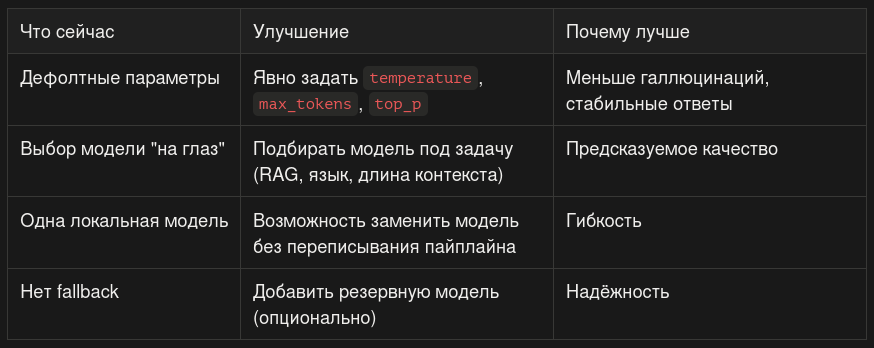

Итоговый код:

In [41]:
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic

# Выбор провайдера: "ollama" или "anthropic"
LLM_PROVIDER = "anthropic"

def llm_part(provider: str = LLM_PROVIDER):
    if provider == "anthropic":
        import os
        from dotenv import load_dotenv
        load_dotenv()
        return ChatAnthropic(
            model="claude-haiku-4-5",
            temperature=0.2,
            max_tokens=1024,
            # top_p не передаём: у Anthropic нельзя одновременно с temperature
        )

    # provider == "ollama"
    try:
        llm = ChatOpenAI(
            api_key="None",
            base_url="http://127.0.0.1:11434/v1",
            model="gemma3:4b",
            temperature=0.2,
            max_tokens=1024,
            top_p=0.8,
        )
        # llm.invoke("ping")  # раскомментировать для проверки доступности Ollama
        return llm
    except Exception as e:
        print(f"Ollama недоступна, переключаемся на Anthropic: {e}")
        return llm_part("anthropic")

### Почему это лучше

- **Низкая температура** → модель меньше "додумывает" вне контекста.
- **Ограничение `max_tokens`** → ответы стабильные по длине.
- **Instruction-модель** → лучше следует системному промпту.
- Код остаётся **совместимым с любым OpenAI-like backend**.

# LangChain цепочка (LCEL RAG chain)



## 1. Что делает цепочка в RAG

LangChain-цепочка в стиле LCEL (LangChain Expression Language) – это **последовательность шагов**, которые связываются оператором `|`:

1. берём вопрос пользователя;
2. через retriever достаём контекст;
3. форматируем его;
4. подставляем всё в промпт;
5. вызываем LLM;
6. приводим ответ к нужному виду.

Каждый такой шаг – это `Runnable`: объект, который умеет принять вход и выдать выход.

Плюс LCEL даёт "из коробки" синхронный/асинхронный запуск, батчи и стриминг, если цепочка собрана через `|`.

В твоём случае цепочка – это один объект `rag_chain`, который можно дернуть так:

In [ ]:
rag_lab_chain.invoke("Что такое MT-LAB?")

## 2. Какие есть возможности у LCEL-цепочек

LCEL (Runnable API) – это новый рекомендованный способ собирать пайплайны в LangChain.

**Что важно знать:**

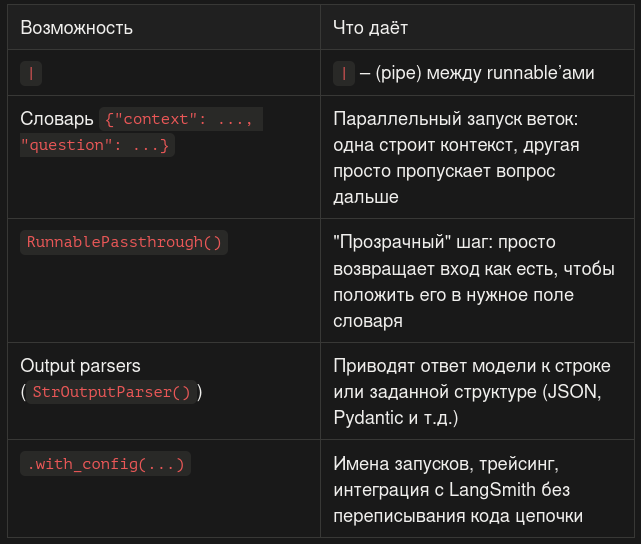

Идея: **цепочка = декларативное описание всего RAG-процесса** от вопроса до финальной строки ответа.

---

## 3. Оптимизация конкретной цепочки

### Текущий код

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm_part()
    | StrOutputParser()
)

### Что он делает по шагам

1. На вход цепочки приходит **строка-вопрос** (`"Какая мебель продается?"`).
2. Словарь `{"context": ..., "question": ...}` работает так:
    - в ветку `"context"` идёт вопрос → `retriever` достаёт документы → `format_docs` превращает их в строку контекста;
    - в ветку `"question"` тот же вопрос просто проходит через `RunnablePassthrough()` без изменений.
3. Получившийся словарь `{"context": "...", "question": "..."}` передаётся в `prompt` и подставляется в шаблон.
4. Затем в `llm` → модель генерирует ответ.
5. `StrOutputParser()` забирает из ответа "голый" текст.

Это **правильный базовый RAG-пайплайн** в стиле официальных примеров.

### Основные недостатки/упущенные возможности

1. **Нет явного поведения при пустом контексте**
    
    Если retriever ничего не нашёл (или вернул мусор), в `context` может прийти пустая строка.
    
    Сейчас цепочка молча передаст это в промпт, и модель будет "додумывать" по памяти, хотя мы хотим RAG "только по базе".
    
2. **Нет имени/конфига для трейсинга**
    
    Цепочка без `.with_config` менее удобна для:
    
    - debugging;
    - логирования;
    - анализа в LangSmith / логах.
3. **Цепочка жёстко завязана только на один вид входа**
    
    Сейчас она принимает **только строку-вопрос**.
    
    Если захочешь добавить, например, `history` или какие-то флаги (`mode: "faq"|"terms"`), код придётся пересобирать.

### Итоговый код

Сделаем **минимальные, но реально полезные** изменения:

- добавим шаг, который подменяет пустой контекст в явное сообщение;
- дадим цепочке имя для трейсинга/логов.

In [42]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

def ensure_context(input_dict: dict) -> dict:
    """
    Если retriever не нашёл ничего полезного и контекст пустой,
    явно помечаем это в контексте, чтобы модель не фантазировала.
    """
    context = input_dict.get("context", "").strip()
    if not context:
        input_dict["context"] = (
            "Контекст пуст: ретривер не нашёл ни одного подходящего фрагмента. "
            "Ответ важен, лучше явно сказать пользователю об этом и прислать предложение связаться напрямую по телефону и другим методам связи."
        )
    return input_dict

rag_lab_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough(),
        "history": lambda _: [],  # пока истории нет – передаём пустой список
    }
    | RunnableLambda(ensure_context)   # защита от пустого контекста
    | prompt
    | llm_part()
    | StrOutputParser()
).with_config(run_name="rag_lab_chain")


Почему это лучше:

- **Чёткое поведение при пустом контексте**
    
    Модель получает явный текст про то, что база ничего не нашла, а не "пустоту", и меньше шансов, что она начнёт уверенно придумывать.
    
- **Легче дебажить и мониторить**
    
    `run_name="rag_lab_chain"` помогает в логах и трейсинге – сразу видно, какой именно пайплайн отработал.
    
- **Структура остаётся простой**
    
    Всё тот же знакомый шаблон:
    
    `{"context": ... , "question": ...} | ... | prompt | llm | parser`,
    
    но уже с одним аккуратным "safety-guard" шагом.
    
- Добавили возможность передавать историю.

In [43]:
print(rag_lab_chain.invoke("Что такое MT-LAB?"))

На основе предоставленного контекста:

**MT-LAB** — это компания (ООО "МТ-ЛАБ"), которая является официальным дилером и поставляет в Екатеринбург широкий ассортимент высококачественной лабораторной мебели и оборудования.

Основные характеристики компании:

- **Специализация**: поставки лабораторной мебели, медицинского оборудования и лабораторного оборудования
- **Услуги**: проектирование, доставка и монтаж оборудования на месте эксплуатации
- **Предложение**: как отдельные компоненты, так и комплектные решения "под ключ"
- **Преимущество**: благодаря статусу официального дилера предлагает доступные цены
- **Продукция**: лабораторная мебель серий "Эксперт" и "ЕвроЭксперт", которая показала высокие эксплуатационные характеристики в лабораториях горнодобывающей, металлургической, химической и других отраслей промышленности

**Контакты**: 
- Телефон: +7(343) 271-69-47, +7(343) 370-28-46
- Email: mt-lab@mt-lab.su, mt-lab@list.ru

Sources: https://mt-lab.su/ (основная информация о компании)

In [44]:
print(rag_lab_chain.invoke("Какую мебель продают в MT-LAB?"))

На основе предоставленной информации, MT-LAB продает следующую лабораторную мебель:

**Основные типы мебели:**
- Столы
- Стулья
- Тумбы
- Шкафы (включая шкафы вытяжные для нагревательных печей)
- Столы-мойки

**Серии мебели:**
- Серия **Эксперт**
- Серия **ЕвроЭксперт**

**Характеристики предлагаемой мебели:**
- Высокие эксплуатационные характеристики
- Цельнометаллическая конструкция
- Эргономичный дизайн
- Единое стилевое решение
- Возможность улучшенной комплектации

Мебель показала хорошие результаты в лабораториях горнодобывающей, металлургической, химической и других отраслей промышленности.

MT-LAB предлагает как отдельные компоненты, так и комплектации под ключ с проектированием, доставкой и монтажом на месте эксплуатации.

**Источники:** https://mt-lab.su/ (основная информация о компании и ассортименте)


In [47]:
print(rag_lab_chain.invoke("Способы связи?"))

На основе предоставленного контекста, вот способы связи с MT-LAB:

**Телефоны:**
- +7(343) 271-69-47
- +7(343) 370-28-46

**Электронная почта:**
- mt-lab@mt-lab.su
- mt-lab@list.ru

Sources: https://mt-lab.su/ (footer-contacts section)
